# Template: Platonic Init Experiment Overview

This notebook is a reusable overview for one experiment and covers:
1. **Pre-pretraining** curves by seed (formal-language training).
2. **Analysis** quality of analytic fits.
3. **Pretraining** downstream validation-loss curves by initialization choice.


In [14]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120


def find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root')

ROOT = find_repo_root()

# ----- Select experiment here -----
EXPERIMENT_NAME = 'dyck_d10_20k_demo'
MODEL_KEY = 'sshleifer_tiny-gpt2'

RUNS_PREPRETRAIN = ROOT / 'runs' / 'prepretraining' / EXPERIMENT_NAME / MODEL_KEY
ART_ANALYSIS = ROOT / 'artifacts' / 'experiments' / EXPERIMENT_NAME / 'analysis'
ART_BASIS_SWEEP = ART_ANALYSIS / 'basis_sweep'
ART_PRETRAIN = ROOT / 'artifacts' / 'experiments' / EXPERIMENT_NAME / 'pretraining'
CURVES_PATH = ART_PRETRAIN / 'init_eval_basis_curves.json'

print('RUNS_PREPRETRAIN:', RUNS_PREPRETRAIN)
print('ART_ANALYSIS:', ART_ANALYSIS)
print('ART_BASIS_SWEEP:', ART_BASIS_SWEEP)
print('ART_PRETRAIN:', ART_PRETRAIN)
print('CURVES_PATH exists:', CURVES_PATH.exists())


RUNS_PREPRETRAIN: /Users/jacksonpetty/Development/platonic-init/runs/prepretraining/dyck_d10_20k_demo/sshleifer_tiny-gpt2
ART_ANALYSIS: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_d10_20k_demo/analysis
ART_BASIS_SWEEP: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_d10_20k_demo/analysis/basis_sweep
ART_PRETRAIN: /Users/jacksonpetty/Development/platonic-init/artifacts/experiments/dyck_d10_20k_demo/pretraining
CURVES_PATH exists: True


## Pre-pretraining Curves by Seed


In [15]:
def latest_trainer_state(seed_dir: Path) -> Path | None:
    ckpts = []
    for p in seed_dir.glob('checkpoint-*'):
        if not p.is_dir():
            continue
        try:
            step = int(p.name.split('-')[-1])
        except ValueError:
            continue
        state = p / 'trainer_state.json'
        if state.exists():
            ckpts.append((step, state))
    if not ckpts:
        return None
    ckpts.sort(key=lambda x: x[0])
    return ckpts[-1][1]

seed_dirs = sorted([p for p in RUNS_PREPRETRAIN.glob('seed_*') if p.is_dir()])
rows = []
for seed_dir in seed_dirs:
    seed_name = seed_dir.name
    state_path = latest_trainer_state(seed_dir)
    if state_path is None:
        continue
    state = json.loads(state_path.read_text(encoding='utf-8'))
    for entry in state.get('log_history', []):
        if 'loss' not in entry or 'step' not in entry:
            continue
        rows.append({
            'seed': seed_name,
            'step': int(entry['step']),
            'loss': float(entry['loss']),
        })

prepretrain_df = pd.DataFrame(rows).sort_values(['seed', 'step']).reset_index(drop=True)
print('Seeds with curves:', prepretrain_df['seed'].nunique())
print('Rows:', len(prepretrain_df))
prepretrain_df.head()


Seeds with curves: 2
Rows: 44


,seed,step,loss
0,seed_0,10,1.782431
1,seed_0,20,1.772377
2,seed_0,30,1.765541
3,seed_0,40,1.759263
4,seed_0,50,1.752207


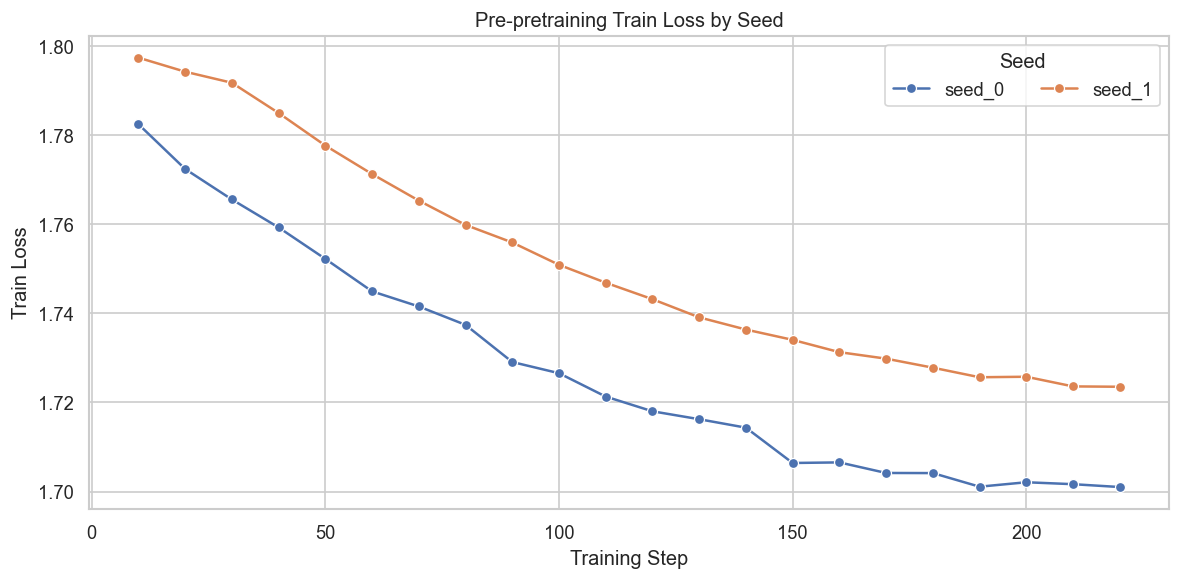

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=prepretrain_df, x='step', y='loss', hue='seed', marker='o')
plt.title('Pre-pretraining Train Loss by Seed')
plt.xlabel('Training Step')
plt.ylabel('Train Loss')
plt.legend(title='Seed', loc='best', ncol=2)
plt.tight_layout()
plt.show()


## Analysis: Analytic Fit Quality by Fit Block


In [17]:
fit_blocks_manifest_path = ART_BASIS_SWEEP / 'fit_blocks.json'
fit_manifest = {}
if fit_blocks_manifest_path.exists():
    fit_manifest = json.loads(fit_blocks_manifest_path.read_text(encoding='utf-8'))

fit_rows = []
for p in sorted(ART_BASIS_SWEEP.glob('analytic_fit_report_*.json')):
    slug = p.stem.replace('analytic_fit_report_', '')
    if slug == '':
        continue
    report = json.loads(p.read_text(encoding='utf-8'))

    fit_name = slug
    basis_type = slug
    for name, meta in fit_manifest.items():
        if meta.get('slug') == slug:
            fit_name = name
            basis_type = meta.get('basis_type', slug)
            break

    fit_rows.append({
        'fit_name': fit_name,
        'basis_type': basis_type,
        'slug': slug,
        'mean_relative_error': float(report['mean_relative_error']),
    })

fit_df = pd.DataFrame(fit_rows).sort_values('fit_name').reset_index(drop=True)
fit_df


,basis,mean_relative_error
0,chebyshev,0.114306
1,fourier,0.578388
2,poly_exp,0.121389
3,rbf,0.190833


/var/folders/70/m9xv6w4j3bl15rm0jsz76ltm0000gn/T/ipykernel_76569/4023470801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fit_df, x='basis', y='mean_relative_error', palette='Blues_r')


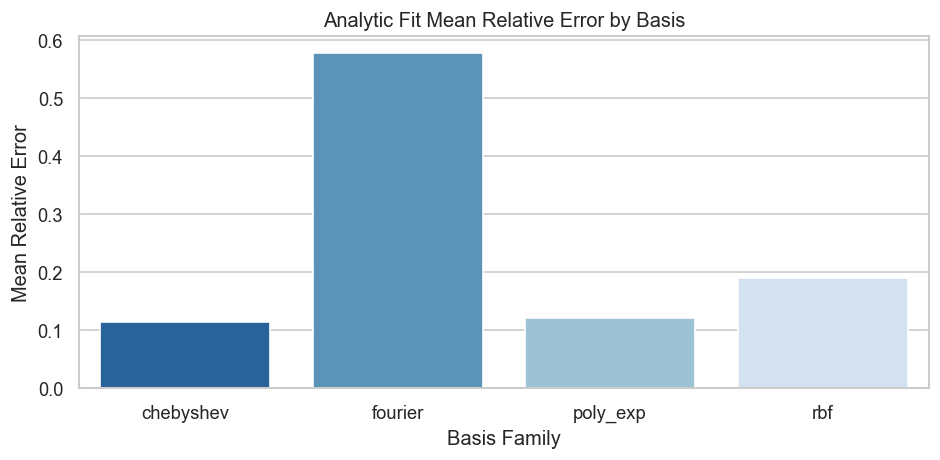

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(data=fit_df, x='fit_name', y='mean_relative_error', palette='Blues_r')
plt.title('Analytic Fit Mean Relative Error by Fit Block')
plt.xlabel('Fit Block')
plt.ylabel('Mean Relative Error')
plt.tight_layout()
plt.show()


## Pretraining: Downstream Validation-Loss Curves by Initialization
Includes random, basis-derived initialization(s), and weight transfer control.


In [19]:
payload = json.loads(CURVES_PATH.read_text(encoding='utf-8'))
results = payload['results']
print('init_mode:', payload.get('init_mode'))
print('train_steps:', payload.get('train_steps'))
print('eval_every:', payload.get('eval_every'))
print('labels:', [r['label'] for r in results])

summary_rows = []
curve_rows = []
for r in results:
    label = r['label']
    summary_rows.append({
        'init': label,
        'initial_eval_loss': float(r.get('initial_eval_loss', float('nan'))),
        'best_eval_loss': float(r.get('best_eval_loss', float('nan'))),
        'final_eval_loss': float(r.get('final_eval_loss', r.get('eval_loss', float('nan')))),
    })
    for point in r.get('eval_curve', []):
        curve_rows.append({
            'init': label,
            'step': int(point['step']),
            'eval_loss': float(point['eval_loss']),
        })

summary_df = pd.DataFrame(summary_rows).sort_values('final_eval_loss').reset_index(drop=True)
curve_df = pd.DataFrame(curve_rows).sort_values(['init', 'step']).reset_index(drop=True)
summary_df


init_mode: sampled
train_steps: 200
eval_every: 10
labels: ['random', 'chebyshev', 'fourier', 'rbf', 'poly_exp', 'weight_transfer_seed_0']


,init,initial_eval_loss,best_eval_loss,final_eval_loss
0,rbf,10.570980,10.497861,10.497861
1,chebyshev,10.570985,10.497937,10.497937
2,random,10.576052,10.500370,10.500370
3,fourier,10.572439,10.500471,10.500471
4,weight_transfer_seed_0,10.578712,10.508197,10.508197
5,poly_exp,10.580926,10.516621,10.516621


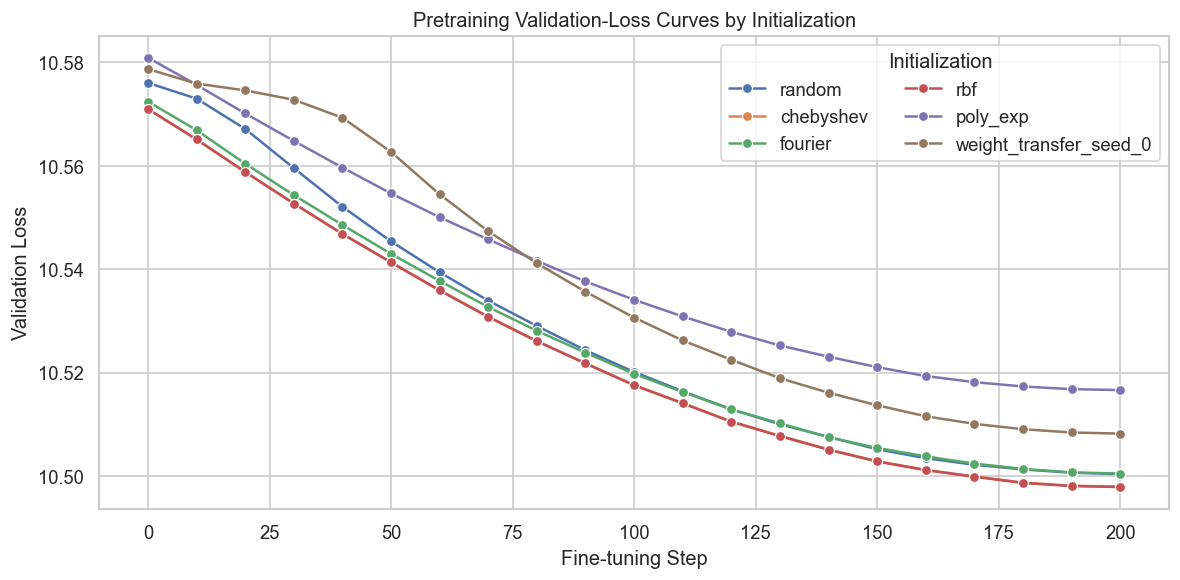

In [20]:
preferred_order = ['random']
preferred_order.extend(payload.get('fit_names', []))
if 'weight_transfer_seed_0' in set(curve_df['init']):
    preferred_order.append('weight_transfer_seed_0')

available = [x for x in preferred_order if x in set(curve_df['init'])]
remaining = sorted([x for x in set(curve_df['init']) if x not in available])
hue_order = available + remaining

plt.figure(figsize=(10, 5))
sns.lineplot(data=curve_df, x='step', y='eval_loss', hue='init', hue_order=hue_order, marker='o')
plt.title('Pretraining Validation-Loss Curves by Initialization')
plt.xlabel('Fine-tuning Step')
plt.ylabel('Validation Loss')
plt.legend(title='Initialization', loc='best', ncol=2)
plt.tight_layout()
plt.show()
